# Classificazione di lesioni dermatologiche con CNN

The skin is the most extended organ in the human body functioning as a bareer against chemical, physical and biological hazard. At an histological level, the skin is a multi-layer organ, each caraterized by different cell populations with different functions. The ever-changing internal and external stimulus can generate alterations in the properites of cells, resulting in the formation of abnormal macroscopic structures which can be dangerous. A correct diagnosis and classification of skin lesions can be produced by dermatologists, specialized medical doctors, with the help of a dermatoscope. However, there is a global shortage of expert dermatologists: with ratios ~ 1/100000 citizens in western countries. Delaying the diagnosis can be very dangerous for the pzients, as some of the skin lesions can progress with metastasis in other locations.

In this project I will train a deep learning model based on CNN architecture trying to classify the skin lesions using datas from the `HAM100000` database.

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_pickle('/content/drive/MyDrive/HAM10000_data.pkl')

Mounted at /content/drive


In [ ]:
df.shape

(10015, 8)

In [ ]:
df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image'],
      dtype='object')

In [ ]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,"[[[190, 153, 194], [192, 154, 196], [191, 153,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,"[[[23, 13, 22], [24, 14, 24], [25, 14, 28], [3..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,"[[[185, 127, 137], [189, 133, 147], [194, 136,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,"[[[24, 11, 17], [26, 13, 22], [38, 21, 32], [5..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,"[[[134, 90, 113], [147, 102, 125], [159, 115, ..."


In [ ]:
print(f"Numero di immagini: {len(df['image_id'].unique())} - Numero di lesioni: {len(df['lesion_id'].unique())}")

Numero di immagini: 10015 - Numero di lesioni: 7470


In [ ]:
print(f"Numero di diagnosi: {len(df['dx'].unique())} - {df['dx'].unique()}")

Numero di diagnosi: 7 - ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


Il dataset contiene dunque **10015 righe e 8 colonne**.
Ciascuna riga corrisponde a una singola immagine dermatoscopica di dimensioni **100 × 75 pixel**. Alcune lesioni sono tuttavia rappresentate da più di un'immagine; il numero di lesioni uniche è infatti pari a **7470**.

Le colonne del dataset sono:

1. **`lesion_id`**: codice identificativo della singola lesione. Immagini differenti possono quindi condividere lo stesso `lesion_id` quando rappresentano la stessa lesione.

2. **`image_id`**: codice identificativo univoco della singola immagine.

3. **`dx`**: diagnosi associata alla lesione. Sono presenti **7 differenti classi diagnostiche**:

   1. **`bkl`**: *Benign keratosis-like lesions* — lesioni benigne simil-cheratosiche.
   2. **`nv`**: *Melanocytic nevi* — nevi melanocitici.
   3. **`df`**: *Dermatofibroma* — dermatofibroma.
   4. **`mel`**: *Melanoma* — melanoma.
   5. **`vasc`**: *Vascular lesions* — lesioni vascolari.
   6. **`bcc`**: *Basal cell carcinoma* — carcinoma basocellulare.
   7. **`akiec`**: *Actinic keratoses and intraepithelial carcinoma / Bowen's disease* — cheratosi attiniche e carcinoma intraepiteliale.

4. **`dx_type`**: modalità attraverso cui è stata determinata la diagnosi. Può assumere valori differenti a seconda che la diagnosi sia stata ottenuta, ad esempio, mediante esame istopatologico, follow-up clinico, consenso di esperti o microscopia confocale.

5. **`age`**: età del paziente, espressa in anni. Per alcune osservazioni il valore può essere mancante.

6. **`sex`**: sesso del paziente, generalmente indicato come `male`, `female` oppure `unknown`.

7. **`localization`**: localizzazione anatomica della lesione, ad esempio dorso, arti inferiori, arti superiori, torace, volto, cuoio capelluto, collo e altre sedi corporee.

8. **`image`**: immagine dermatoscopica associata alla riga, rappresentata come un array numerico di dimensioni **100 × 75 × 3**, dove l'ultima dimensione corrisponde ai tre canali di colore rosso, verde e blu.

È importante sottolineare che **il numero di immagini non coincide con il numero di lesioni indipendenti**, poiché una stessa lesione può essere associata a più immagini.

Un'altra osservazione riguardo al dataset è la distribuzione delle diagnosi:

In [ ]:
df_diagnosis_unique = df.drop_duplicates(subset='lesion_id').copy()

comparison = pd.concat(
    [
        df_diagnosis_unique.dx.value_counts(normalize=True),
        df.dx.value_counts(normalize=True)
    ],
    axis=1
)

comparison.columns = ['Unique lesions', 'All images']

comparison

,Unique lesions,All images
dx,,
nv,0.723293,0.669496
bkl,0.097323,0.109735
mel,0.082195,0.111133
bcc,0.043775,0.051323
akiec,0.030522,0.032651
vasc,0.013119,0.014179
df,0.009772,0.011483


Il dataset è dunque fortemente sbilanciato verso la classe `nv`che corrisponde ai nevi benigni: il 72,3% delle lesioni e il 66,9% delle immagini è un nevo benigno. Questa renderà necessario realizzare degli accorgimenti nella fase di training e di valutazione.

Le coppie (images, label) sono state validate, tagliate e centrate dagli autori del database. In alcuni casi un dermatologo ha effettuato delle modifiche manuali all'istogramma per faciitare il riconoscimento. A valle di queste modifiche ho apportato alcune correzioni per preparare i dati all'addestramento del modello:
1. Innanzitutto per permettere l'addestramento del modello è stato necessario trasformare le labels di `dx` in variabili numeriche.

In [ ]:
label_map = {
    'akiec': 0,
    'bcc': 1,
    'bkl': 2,
    'df': 3,
    'mel': 4,
    'nv': 5,
    'vasc': 6
}

Per la prepazione del dataset utilizzo la classe `Dataset` di PyTorch. In questa fase vengono realizzate 3 trasformazioni sui dati:
1. invertire gli ordini degli indici da `(H x W x C)` a `(C x H x W)` per renderlo compatibile con le funzioni PyTorch che si usano successivamente.
2. Normalizzazione dei valori dell'immagine.
3. Data augmentation: per compensare lo sbilanciamento del dataset viene qui implementata una tecnica di data augmentation. L'idea è quella di fare oversampling sulle classi meno numerose praticando una data augmentation più aggressiva per ridurre il rischio di overfitting e migliorare la capacità di generalizzazione.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import  transforms

# Applicazione di una serie di trasformazioni in sequenza
forte_train_trasform = transforms.Compose([

    # Conversione dell'immagine in formato PIL utilizzato dalla libreria torchvision
    transforms.ToPILImage(),

    # Con probabilità = 0.5 ( p = 0.5) ribalta l'immagine orizzontalmente
    transforms.RandomHorizontalFlip(p=0.5),
     # Con probabilità = 0.5 ( p = 0.5) ribalta l'immagine verticalmente
    transforms.RandomVerticalFlip(p=0.5),
    # Ruota casualmente l'immagine di un'angolo tra -20 e +20 gradi
    transforms.RandomRotation(20),


    # Modifica casualmente alcune proprietà cromatiche dell'immagine
    transforms.ColorJitter(
        #Varia luminosità tra il +10% e il -10%
        brightness=0.1,
        #Varia contrasto tra il +10% e il -10%
        contrast=0.1,
        #Varia saturazione tra il +10% e il -10%
        saturation=0.1
    ),

    # Riconverte l'immagine nel formato tensor, realizzando anche le operazioni di permutazione e normalizzazione
    transforms.ToTensor()
])

base_train_trasform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])



class ProjectDataset(Dataset):

  def __init__(self, df, label_map, base_trasform = None, forte_trasform= None):

    self.df = df
    self.label_map = label_map
    self.base_trasform = base_trasform
    self.forte_trasform = forte_trasform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):

    image = self.df['image'].iloc[index]
    label = self.df['dx'].iloc[index]
    label = self.label_map[label]

    if self.base_trasform is not None and self.forte_trasform is not None:

      if label in [0, 1, 3, 6]:

        image = self.forte_trasform(image)

      else:

        image = self.base_trasform(image)

    else:

      image = torch.tensor(image, dtype = torch.float32)

      # Le immagini si trovano nel formato (Height (H) x Width (W) x Channels (C)), ma le funzioni di Torch si aspettano (C x H x W), per cui inverto gli indici dell'immagine

      image = image.permute(2, 0, 1)

      #L'immagine viene normalizzata sul massimo valore per canale in codifica RGB (255)

      image = image / 255.0

      label = torch.tensor(label, dtype = torch.long)

    return image, label

Per quanto concerne il rischio di data leakage, il rischio principale è legato alla presenza di diverse immagini della stessa lesione all'interno del dataset. Il modello potrebbe riconoscere immagini nel test set già incontrate nel train set ottenendo così performance artificialmente alte. Per questo lo split viene realizzato a partire da un database che contiene valori unici per `lesion_id`. Lo schema di training - validation - testing seguirà uno schema di cross validation 5-fold.

In [ ]:
n_unique = len(df_diagnosis_unique)
n_5fold = int(n_unique * 0.85)

#Il dataset viene rimescolato casualmente in modo che eventuali ordini siano eliminati permettendo di garantire che toericamente i due insiemi abbiano la stessa distribuzione
df_diagnosis_unique = df_diagnosis_unique.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

#Divido il dataset in una porzione che contiene l'85% delle lesioni e utilizzerò per la cross validation e il 15% che invece veranno utilizzati nel testing
fold5_lesions = df_diagnosis_unique[:n_5fold]["lesion_id"]
test_lesions = df_diagnosis_unique[n_5fold:]["lesion_id"]

#A partire da questi due insiemi riconsidero le righe non ancora incluse assicurandomi che ogni ogni insieme abbia un lesion id diverso
crossval_df = df[
    df["lesion_id"].isin(fold5_lesions)
].reset_index(drop=True)

test_df = df[
    df["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

#Verifichiamo le dimensioni dei due nuovi insiemi
print(f"Forma del dataset di cross_validation: {crossval_df.shape} - Forma del dataset di testing: {test_df.shape} - Somma di verifica: {crossval_df.shape[0]+test_df.shape[0]}")

#Verifichiamo anche che le distribuzioni delle diagnosi siano simili

comparison = pd.concat(
    [
        crossval_df.dx.value_counts(normalize=True),
        test_df.dx.value_counts(normalize=True)
    ],
    axis=1
)

comparison.columns = ['Validation test', 'Test set']

comparison





Forma del dataset di cross_validation: (8529, 8) - Forma del dataset di testing: (1486, 8) - Somma di verifica: 10015


,Validation test,Test set
dx,,
nv,0.664439,0.698520
mel,0.112205,0.104980
bkl,0.111854,0.097577
bcc,0.051471,0.050471
akiec,0.032946,0.030956
vasc,0.015594,0.006057
df,0.011490,0.011440


## Architettura del modello

Il modello utilizzato è una **rete neurale convoluzionale composta da 4 blocchi**, ciascuno formato da **2 layer convoluzionali**, seguiti da Batch Normalization e funzione di attivazione ReLU.  
Alla fine di ciascun blocco viene applicato un **Max Pooling $2\times2$**, che dimezza progressivamente le dimensioni spaziali dell'immagine.

L'immagine iniziale è rappresentata dal tensore:

$$
x \in \mathbb{R}^{3 \times 75 \times 100}
$$

dove $3$ corrisponde ai tre canali RGB.

### Blocco 1

Il primo blocco contiene due convoluzioni:

$$
3 \rightarrow 48 \rightarrow 48
$$

Le convoluzioni $3\times3$ con padding pari a 1 mantengono invariate le dimensioni spaziali. Il Max Pooling dimezza invece altezza e larghezza:

$$
\mathbb{R}^{3\times75\times100}
\rightarrow
\mathbb{R}^{48\times75\times100}
\rightarrow
\mathbb{R}^{48\times75\times100}
\rightarrow
\mathbb{R}^{48\times37\times50}.
$$

### Blocco 2

$$
48 \rightarrow 96 \rightarrow 96
$$

e quindi:

$$
\mathbb{R}^{48\times37\times50}
\rightarrow
\mathbb{R}^{96\times37\times50}
\rightarrow
\mathbb{R}^{96\times37\times50}
\rightarrow
\mathbb{R}^{96\times18\times25}.
$$

### Blocco 3

$$
96 \rightarrow 192 \rightarrow 192
$$

da cui:

$$
\mathbb{R}^{96\times18\times25}
\rightarrow
\mathbb{R}^{192\times18\times25}
\rightarrow
\mathbb{R}^{192\times18\times25}
\rightarrow
\mathbb{R}^{192\times9\times12}.
$$

### Blocco 4

$$
192 \rightarrow 384 \rightarrow 384
$$

e quindi:

$$
\mathbb{R}^{192\times9\times12}
\rightarrow
\mathbb{R}^{384\times9\times12}
\rightarrow
\mathbb{R}^{384\times9\times12}
\rightarrow
\mathbb{R}^{384\times4\times6}.
$$

Dopo i quattro blocchi convoluzionali viene applicato il **Global Average Pooling**, che calcola la media dei valori di ciascuna delle 384 feature map:

$$
\mathbb{R}^{384\times4\times6}
\rightarrow
\mathbb{R}^{384\times1\times1}
\rightarrow
\mathbb{R}^{384}.
$$

Il vettore risultante viene infine passato attraverso un layer lineare:

$$
\mathbb{R}^{384}
\rightarrow
\mathbb{R}^{7},
$$

ottenendo un logit per ciascuna delle 7 classi diagnostiche.

L'intera trasformazione può quindi essere sintetizzata come:

$$
\boxed{
\mathbb{R}^{3\times75\times100}
\rightarrow
\mathbb{R}^{48\times37\times50}
\rightarrow
\mathbb{R}^{96\times18\times25}
\rightarrow
\mathbb{R}^{192\times9\times12}
\rightarrow
\mathbb{R}^{384\times4\times6}
\rightarrow
\mathbb{R}^{384}
\rightarrow
\mathbb{R}^{7}
}
$$

Per l'addestramento viene utilizzata la **Cross-Entropy Loss**. La funzione Softmax permette successivamente di trasformare i 7 logits prodotti dalla rete in una distribuzione di probabilità sulle 7 categorie diagnostiche.

Per l'implementazione del modello si usa Pytorch:

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Definizione dell'architettura del modello:
    # Layer 1
    self.conv1 = nn.Conv2d(3, 48, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(48)

    #Layer 2
    self.conv2 = nn.Conv2d(48, 48, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(48)

    #Layer 3
    self.conv3 = nn.Conv2d(48, 96, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(96)

    #Layer 4
    self.conv4 = nn.Conv2d(96, 96, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(96)

    #Layer 5
    self.conv5 = nn.Conv2d(96, 192, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(192)

    #Layer 6
    self.conv6 = nn.Conv2d(192, 192, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(192)

    #Layer 7
    self.conv7 = nn.Conv2d(192, 384, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(384)

    #Layer 8
    self.conv8 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(384)


    # Operazione di MaxPooling
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Global Average Pooling: Calcola media artimetica della i-esima feature map 6x4 e la salva nella i-esima cella del vettore finale
    self.gap = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Linear(384, 7)

  def forward(self, x):

    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = self.pool(x)

    x = F.relu(self.bn3(self.conv3(x)))
    x = F.relu(self.bn4(self.conv4(x)))
    x = self.pool(x)

    x = F.relu(self.bn5(self.conv5(x)))
    x = F.relu(self.bn6(self.conv6(x)))
    x = self.pool(x)

    x = F.relu(self.bn7(self.conv7(x)))
    x = F.relu(self.bn8(self.conv8(x)))
    x = self.pool(x)

    x = self.gap(x)

    x = torch.flatten(x, 1)

    x = self.fc(x)

    return x


Passiamo dunque alla parte di training:

In [ ]:
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(crossval_df, groups=crossval_df['lesion_id'])
):

    train_df = crossval_df.iloc[train_idx].reset_index(drop=True)
    val_df = crossval_df.iloc[val_idx].reset_index(drop=True)

    # Da DataFrame pandas i dati vengono trasformati in tensori di Torch
    train_dataset = ProjectDataset(
        train_df,
        label_map,
        base_trasform=base_train_trasform,
        forte_trasform=forte_train_trasform
    )

    val_dataset = ProjectDataset(
        val_df,
        label_map
    )

    # Per ogni riga del Dataset estraggo solo la coppia label e immagine e le organizzo in batch di 32 elementi

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    # Stampa le dimensioni del fold corrente

    print("Training images:", len(train_dataset))
    print("Validation images:", len(val_dataset))

    # Inizializzo i parametri del modello all'inizio di ogni fold

    model = CNN().to(device)

    # Utilizzo come loss la cross entropy

    weights = torch.zeros(len(label_map))

    train_loss_sum = 0
    train_weight_sum = 0

    for label, idx in label_map.items():

      count = (train_df["dx"] == label).sum()

      weights[idx] = len(train_df) / (
        len(label_map) * count
      )

    weights = weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)

    # Definisco il metodo di calcolo dei gradienti e di aggiornamento dei parametri

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    #Inizio del ciclo di train, per ogni epoca: Calcolo le previsioni del modello --> Loss --> Calcolo dei gradienti --> Aggiornamento dei parametri

    best_balanced_acc = 0

    for epoch in range(50):

      model.train()

      train_loss = 0

      for images, label in train_loader:

        images = images.to(device)
        label = label.to(device)
        optimizer.zero_grad()

        #Logits è il vettore di 7 elementi che emerge dopo la softmax, argmax di logits corrisponde alla classe predetta dal modello

        logits = model(images)

        loss = criterion(logits, label)

        loss.backward()

        optimizer.step()

        # La train loss viene aggiornata ad ogni batch sommando il valore precedente con il valore numerico della loss sul batch corrente moltiplicato per la dimensione del batch

        batch_weights = weights[label]

        train_loss_sum += (
            loss.item() * batch_weights.sum().item()
        )

        train_weight_sum += batch_weights.sum().item()

      train_loss = train_loss_sum / train_weight_sum



      # Fase di valutazione


      model.eval()

      val_loss_sum = 0
      val_weight_sum = 0

      val_loss = 0

      all_labels = []

      all_predictions = []

      with torch.no_grad():

        for images, label in val_loader:

          images = images.to(device)
          label = label.to(device)

          logits = model(images)

          loss = criterion(logits, label)

          batch_weights = weights[label]

          val_loss_sum += (
                loss.item() * batch_weights.sum().item()
          )

          val_weight_sum += batch_weights.sum().item()


          prediction = torch.argmax(logits, dim=1)

          # Salvo tutte le coppie (previsione, y_true) per valutare le metriche alla fine

          all_labels.extend(
              label.cpu().numpy()
          )

          all_predictions.extend(
              prediction.cpu().numpy()
          )

      val_loss = val_loss_sum / val_weight_sum

      balanced_acc = balanced_accuracy_score(
            all_labels,
            all_predictions
      )

      macro_f1 = f1_score(
            all_labels,
            all_predictions,
            average="macro"
      )

      if balanced_acc > best_balanced_acc:

        best_balanced_acc = balanced_acc
        torch.save(
            model.state_dict(),
            f"best_model_fold_{fold+1}.pth"
        )


      print(
            f"Epoch {epoch+1} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Balanced accuracy: {balanced_acc:.4f} | "
            f"Macro F1: {macro_f1:.4f}"
        )






Training images: 6823
Validation images: 1706
Epoch 1 | Train loss: 1.5513 | Val loss: 1.5657 | Balanced accuracy: 0.4270 | Macro F1: 0.3483
Epoch 2 | Train loss: 1.4360 | Val loss: 1.3092 | Balanced accuracy: 0.5050 | Macro F1: 0.3893
Epoch 3 | Train loss: 1.3702 | Val loss: 1.3191 | Balanced accuracy: 0.4853 | Macro F1: 0.3898
Epoch 4 | Train loss: 1.3260 | Val loss: 1.4327 | Balanced accuracy: 0.4892 | Macro F1: 0.4299
Epoch 5 | Train loss: 1.2866 | Val loss: 1.3943 | Balanced accuracy: 0.5109 | Macro F1: 0.3648
Epoch 6 | Train loss: 1.2565 | Val loss: 1.2974 | Balanced accuracy: 0.5242 | Macro F1: 0.4273
Epoch 7 | Train loss: 1.2286 | Val loss: 1.2337 | Balanced accuracy: 0.5774 | Macro F1: 0.4559
Epoch 8 | Train loss: 1.2057 | Val loss: 1.3488 | Balanced accuracy: 0.5334 | Macro F1: 0.4720
Epoch 9 | Train loss: 1.1855 | Val loss: 1.2481 | Balanced accuracy: 0.5538 | Macro F1: 0.4684
Epoch 10 | Train loss: 1.1634 | Val loss: 1.2660 | Balanced accuracy: 0.5546 | Macro F1: 0.4783
Epo

Carichiamo ora i risultati dei modelli che hanno raggiunto una migliore balanced accuracy per ogni fold e ricostruiamone la confusion matrix:

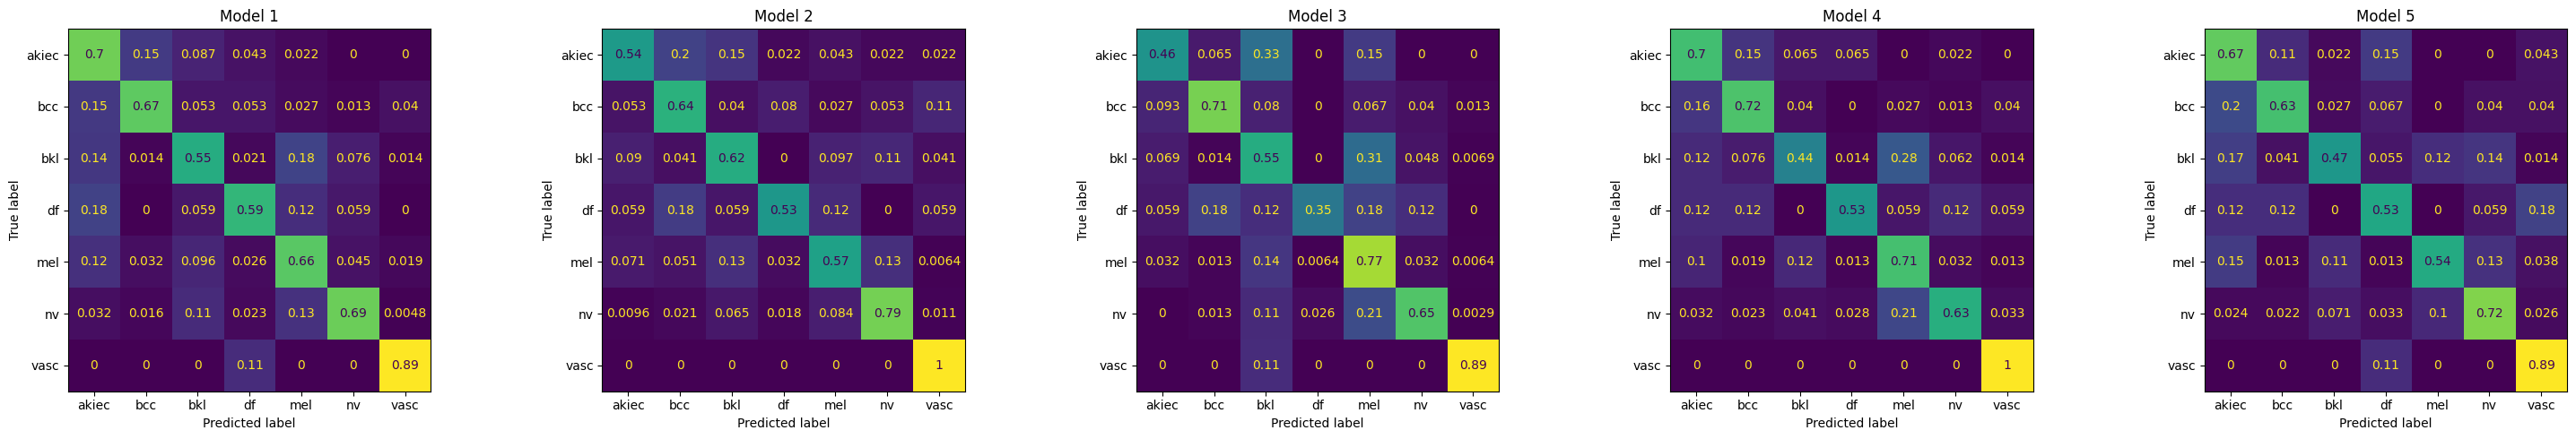


--- MODEL 1 ---
Accuracy: 0.6709
Balanced Accuracy: 0.6770
Macro Precision: 0.4577
Macro Recall: 0.6770
Macro F1: 0.5151

--- MODEL 2 ---
Accuracy: 0.7349
Balanced Accuracy: 0.6709
Macro Precision: 0.4629
Macro Recall: 0.6709
Macro F1: 0.5189

--- MODEL 3 ---
Accuracy: 0.6454
Balanced Accuracy: 0.6246
Macro Precision: 0.5059
Macro Recall: 0.6246
Macro F1: 0.5333

--- MODEL 4 ---
Accuracy: 0.6258
Balanced Accuracy: 0.6742
Macro Precision: 0.4216
Macro Recall: 0.6742
Macro F1: 0.4643

--- MODEL 5 ---
Accuracy: 0.6696
Balanced Accuracy: 0.6361
Macro Precision: 0.4102
Macro Recall: 0.6361
Macro F1: 0.4524

MEDIA SUI 5 MODELLI
Accuracy: 0.6693 ± 0.0368
Balanced Accuracy: 0.6566 ± 0.0218
Macro Precision: 0.4517 ± 0.0339
Macro Recall: 0.6566 ± 0.0218
Macro F1: 0.4968 ± 0.0322


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_df = test_df.reset_index(drop=True)

test_df_torch = ProjectDataset(test_df, label_map)


test_loader = DataLoader(
    test_df_torch,
    batch_size=32,
    shuffle=False
)


# ============================================================
# CARICAMENTO MODELLI
# ============================================================

model_1 = CNN()
model_1.load_state_dict(torch.load("best_model_fold_1.pth"))

model_2 = CNN()
model_2.load_state_dict(torch.load("best_model_fold_2.pth"))

model_3 = CNN()
model_3.load_state_dict(torch.load("best_model_fold_3.pth"))

model_4 = CNN()
model_4.load_state_dict(torch.load("best_model_fold_4.pth"))

model_5 = CNN()
model_5.load_state_dict(torch.load("best_model_fold_5.pth"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1 = model_1.to(device)
model_2 = model_2.to(device)
model_3 = model_3.to(device)
model_4 = model_4.to(device)
model_5 = model_5.to(device)


models = [
    model_1,
    model_2,
    model_3,
    model_4,
    model_5
]


# ============================================================
# TEST
# ============================================================

results = []
confusion_matrices = []

for i, current_model in enumerate(models, start=1):

    current_model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = current_model(images)

            predicted = torch.argmax(
                logits,
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

    # Confusion matrix

    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize="true"
    )

    confusion_matrices.append(cm)


    # Metriche

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    results.append({
        "model": i,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    })


# ============================================================
# CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(
    1,
    5,
    figsize=(30, 5)
)

class_names = [
    label
    for label, index in sorted(
        label_map.items(),
        key=lambda x: x[1]
    )
]

for i, cm in enumerate(confusion_matrices):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(
        f"Model {i+1}"
    )


plt.tight_layout()
plt.show()


# ============================================================
# RISULTATI DEI SINGOLI MODELLI
# ============================================================

for result in results:

    print(
        f"\n--- MODEL {result['model']} ---"
    )

    print(
        f"Accuracy: "
        f"{result['accuracy']:.4f}"
    )

    print(
        f"Balanced Accuracy: "
        f"{result['balanced_accuracy']:.4f}"
    )

    print(
        f"Macro Precision: "
        f"{result['macro_precision']:.4f}"
    )

    print(
        f"Macro Recall: "
        f"{result['macro_recall']:.4f}"
    )

    print(
        f"Macro F1: "
        f"{result['macro_f1']:.4f}"
    )


# ============================================================
# MEDIA SUI 5 MODELLI
# ============================================================

accuracy_values = np.array([
    result["accuracy"]
    for result in results
])

balanced_accuracy_values = np.array([
    result["balanced_accuracy"]
    for result in results
])

macro_precision_values = np.array([
    result["macro_precision"]
    for result in results
])

macro_recall_values = np.array([
    result["macro_recall"]
    for result in results
])

macro_f1_values = np.array([
    result["macro_f1"]
    for result in results
])


print("\n==========================")
print("MEDIA SUI 5 MODELLI")
print("==========================")


print(
    f"Accuracy: "
    f"{accuracy_values.mean():.4f} ± "
    f"{accuracy_values.std():.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_values.mean():.4f} ± "
    f"{balanced_accuracy_values.std():.4f}"
)

print(
    f"Macro Precision: "
    f"{macro_precision_values.mean():.4f} ± "
    f"{macro_precision_values.std():.4f}"
)

print(
    f"Macro Recall: "
    f"{macro_recall_values.mean():.4f} ± "
    f"{macro_recall_values.std():.4f}"
)

print(
    f"Macro F1: "
    f"{macro_f1_values.mean():.4f} ± "
    f"{macro_f1_values.std():.4f}"
)

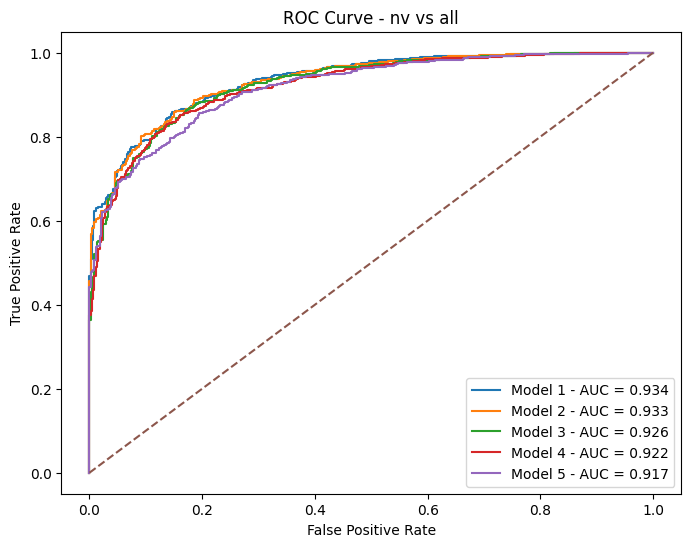

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

models = [
    model_1,
    model_2,
    model_3,
    model_4,
    model_5
]

nv_index = label_map["nv"]

auc_values = []

plt.figure(figsize=(8, 6))


for i, current_model in enumerate(models, start=1):

    current_model = current_model.to(device)
    current_model.eval()

    y_true_nv = []
    y_score_nv = []

    with torch.inference_mode():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = current_model(images)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            nv_probabilities = probabilities[:, nv_index]

            binary_labels = (
                labels == nv_index
            ).int()

            y_true_nv.extend(
                binary_labels.cpu().numpy()
            )

            y_score_nv.extend(
                nv_probabilities.cpu().numpy()
            )


    auc = roc_auc_score(
        y_true_nv,
        y_score_nv
    )

    auc_values.append(auc)

    fpr, tpr, thresholds = roc_curve(
        y_true_nv,
        y_score_nv
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Model {i} - AUC = {auc:.3f}"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - nv vs all")
plt.legend()

plt.show()

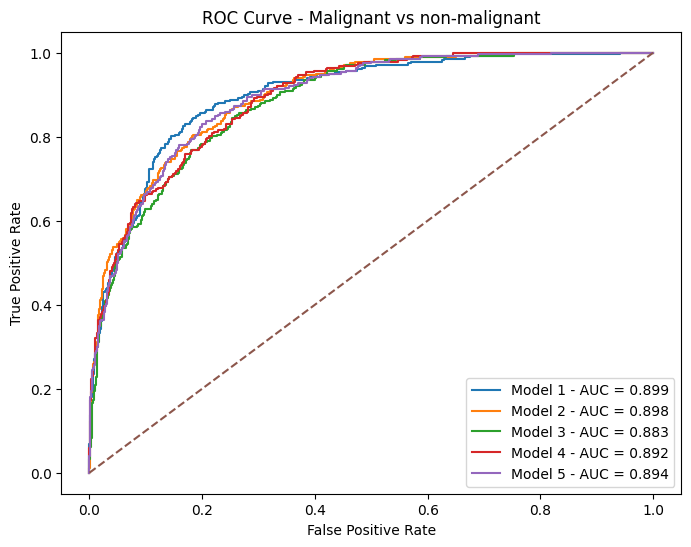

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


models = [
    model_1,
    model_2,
    model_3,
    model_4,
    model_5
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Indici delle classi maligne

mel_index = label_map["mel"]
bcc_index = label_map["bcc"]
akiec_index = label_map["akiec"]


auc_values = []

plt.figure(figsize=(8, 6))


for i, current_model in enumerate(models, start=1):

    current_model = current_model.to(device)
    current_model.eval()

    y_true_malignant = []
    y_score_malignant = []


    with torch.inference_mode():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = current_model(images)

            probabilities = torch.softmax(
                logits,
                dim=1
            )


            # Probabilità che la lesione sia maligna

            malignant_probabilities = (
                probabilities[:, mel_index]
                + probabilities[:, bcc_index]
                + probabilities[:, akiec_index]
            )


            # Vera classe binaria:
            # 1 = maligna
            # 0 = non maligna

            binary_labels = (
                (labels == mel_index)
                | (labels == bcc_index)
                | (labels == akiec_index)
            ).int()


            y_true_malignant.extend(
                binary_labels.cpu().numpy()
            )

            y_score_malignant.extend(
                malignant_probabilities.cpu().numpy()
            )


    # AUC

    auc = roc_auc_score(
        y_true_malignant,
        y_score_malignant
    )

    auc_values.append(auc)


    # ROC

    fpr, tpr, thresholds = roc_curve(
        y_true_malignant,
        y_score_malignant
    )


    plt.plot(
        fpr,
        tpr,
        label=f"Model {i} - AUC = {auc:.3f}"
    )


# Classificatore casuale

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Malignant vs non-malignant"
)

plt.legend()

plt.show()
